Implement inverse transform sampling for the exponential distribution. Verify by sampling 10,000 values and comparing the histogram to the true PDF.

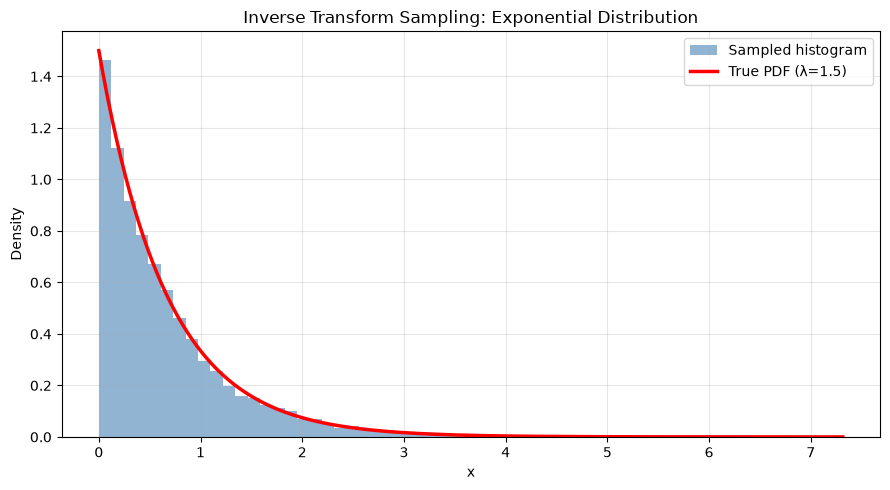

Sample mean:     0.6592  (expected 1/λ = 0.6667)
Sample variance: 0.4475  (expected 1/λ² = 0.4444)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Inverse transform sampling ---
def sample_exponential(lam, n):
    u = np.random.uniform(0, 1, n)     # uniform samples
    x = -np.log(u) / lam               # inverse CDF transform
    return x

# --- Step 2: Generate samples ---
lam = 1.5            # rate parameter
n = 10_000
samples = sample_exponential(lam, n)

# --- Step 3: True PDF ---
x_vals = np.linspace(0, samples.max(), 500)
true_pdf = lam * np.exp(-lam * x_vals)

# --- Step 4: Plot histogram vs true PDF ---
plt.figure(figsize=(9, 5))
plt.hist(samples, bins=60, density=True,
         alpha=0.6, color='steelblue', label='Sampled histogram')
plt.plot(x_vals, true_pdf, 'r-', linewidth=2.5, label=f'True PDF (λ={lam})')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Inverse Transform Sampling: Exponential Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Step 5: Quantitative check ---
print(f"Sample mean:     {samples.mean():.4f}  (expected 1/λ = {1/lam:.4f})")
print(f"Sample variance: {samples.var():.4f}  (expected 1/λ² = {1/lam**2:.4f})")